In [1]:
import pandas as pd
import numpy as np
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# Make plots look nice in the notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
print("📥 Downloading official AI4I 2020 dataset from UCI Repository...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

print(f"✅ Data downloaded! Shape: {df.shape}")
df.head()


📥 Downloading official AI4I 2020 dataset from UCI Repository...
✅ Data downloaded! Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# 1. Drop identifiers to prevent data leakage
df = df.drop(columns=['UDI', 'Product ID'], errors='ignore')

# 2. Clean column names (remove brackets and spaces)
df.columns = [col.replace(' ', '_').replace('[', '').replace(']', '') for col in df.columns]

print(df.columns.tolist())
print([repr(c) for c in df.columns])  # shows hidden spaces

# normalize column names
df.columns = df.columns.str.strip()

# find Type case-insensitively
type_col = next((c for c in df.columns if c.lower() == "type"), None)
if type_col is None:
    raise KeyError(f"'Type' column not found. Available columns: {df.columns.tolist()}")

df = pd.get_dummies(df, columns=[type_col], drop_first=True)

# 4. Feature Engineering (Domain knowledge injections)
df['Temp_diff_K'] = df['Process_temperature_K'] - df['Air_temperature_K']
df['Power_W'] = df['Rotational_speed_rpm'] * df['Torque_Nm']

# 5. Define Features (X) and Target (y)
# Dropping the specific failure modes to prevent target leakage
X = df.drop(columns=['Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df['Machine_failure']

print("Features ready for modeling:")
X.head()

['Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
["'Type'", "'Air_temperature_K'", "'Process_temperature_K'", "'Rotational_speed_rpm'", "'Torque_Nm'", "'Tool_wear_min'", "'Machine_failure'", "'TWF'", "'HDF'", "'PWF'", "'OSF'", "'RNF'"]
Features ready for modeling:


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_L,Type_M,Temp_diff_K,Power_W
0,298.1,308.6,1551,42.8,0,False,True,10.5,66382.8
1,298.2,308.7,1408,46.3,3,True,False,10.5,65190.4
2,298.1,308.5,1498,49.4,5,True,False,10.4,74001.2
3,298.2,308.6,1433,39.5,7,True,False,10.4,56603.5
4,298.2,308.7,1408,40.0,9,True,False,10.5,56320.0


In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
# Remember: class_weight='balanced' handles the rare occurrence of actual failures
print("🧠 Training Random Forest...")
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
print("✅ Training complete.")

🧠 Training Random Forest...
✅ Training complete.


Accuracy: 98.70%
Average Inference Latency: 0.0686 milliseconds per prediction

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.91      0.64      0.75        61

    accuracy                           0.99      2000
   macro avg       0.95      0.82      0.87      2000
weighted avg       0.99      0.99      0.99      2000



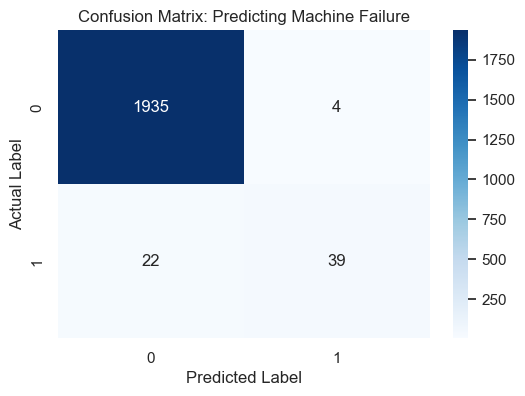

In [5]:
# Measure Inference Latency
start_time = time.time()
y_pred = model.predict(X_test)
end_time = time.time()

inference_time_ms = ((end_time - start_time) / len(X_test)) * 1000

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Average Inference Latency: {inference_time_ms:.4f} milliseconds per prediction\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot a Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicting Machine Failure')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

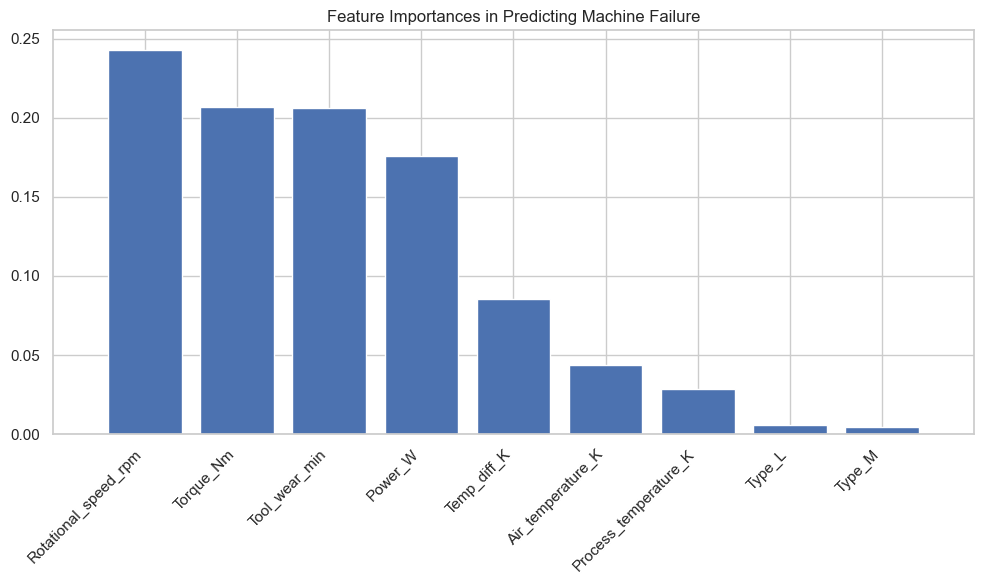

In [6]:
# Plot Feature Importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances in Predicting Machine Failure")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45, ha='right')
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

In [7]:
# Create the models directory if it doesn't exist
os.makedirs("models", exist_ok=True)
model_path = "models/rf_model.joblib"

artifact = {
    'model': model,
    'features': list(X.columns)
}
joblib.dump(artifact, model_path)
print(f"✅ Model successfully saved to {model_path} ready for API deployment.")


✅ Model successfully saved to models/rf_model.joblib ready for API deployment.
